In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yacharki/amazon-reviews-for-sa-binary-negative-positive-csv")

print("Path to dataset files:", path)

c:\Users\sbiradar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\sbiradar\.cache\kagglehub\datasets\yacharki\amazon-reviews-for-sa-binary-negative-positive-csv\versions\5


In [2]:
import pandas as pd

# Define the base path
base_path = r"C:\Users\sbiradar\.cache\kagglehub\datasets\yacharki\amazon-reviews-for-sa-binary-negative-positive-csv\versions\5\amazon_review_sa_binary_csv"

# Read the train and test CSV files
print("Reading the CSV files...")
train_df = pd.read_csv(f"{base_path}/train.csv")
test_df = pd.read_csv(f"{base_path}/test.csv")

# Display column names
print("\nTraining dataset columns:")
print(train_df.columns.tolist())
print("\nTest dataset columns:")
print(test_df.columns.tolist())

# Display basic information about the datasets
print("\nTraining Dataset Info:")
print(train_df.info())
print("\nTest Dataset Info:")
print(test_df.info())

# Display the first few rows of each dataset
print("\nFirst 5 rows of training dataset:")
print(train_df.head())
print("\nFirst 5 rows of test dataset:")
print(test_df.head())

# Display basic statistics
print("\nTraining dataset statistics:")
print(train_df.describe())
print("\nTest dataset statistics:")
print(test_df.describe())

Reading the CSV files...

Training dataset columns:
['class_index', 'review_title', 'review_text']

Test dataset columns:
['class_index', 'review_title', 'review_text']

Training Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   class_index   int64 
 1   review_title  object
 2   review_text   object
dtypes: int64(1), object(2)
memory usage: 82.4+ MB
None

Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   class_index   400000 non-null  int64 
 1   review_title  399976 non-null  object
 2   review_text   400000 non-null  object
dtypes: int64(1), object(2)
memory usage: 9.2+ MB
None

First 5 rows of training dataset:
   class_index                                       review_title  \
0    


Class distribution in training dataset:
class_index
2    1800000
1    1800000
Name: count, dtype: int64

Class distribution in test dataset:
class_index
2    200000
1    200000
Name: count, dtype: int64


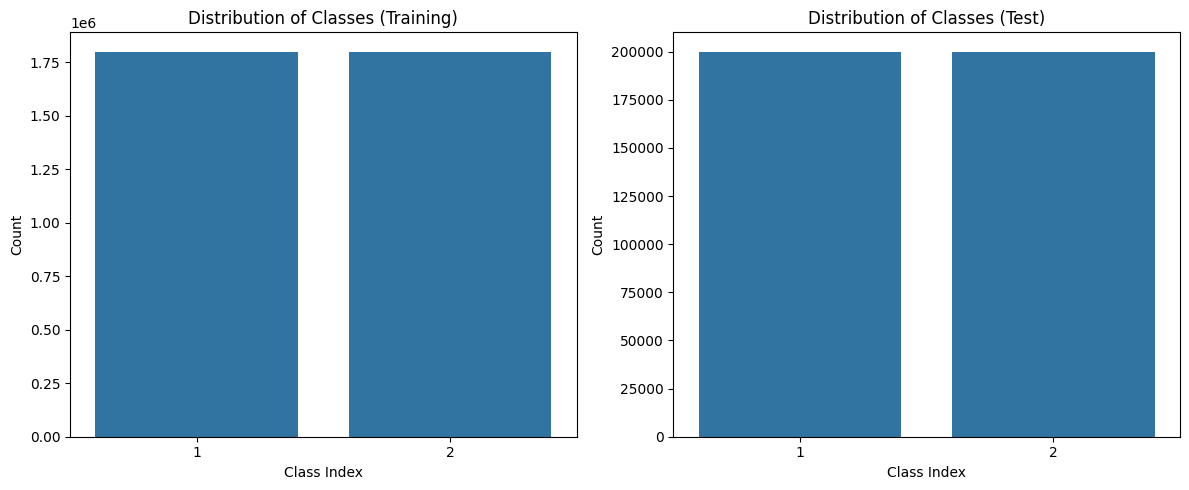


Sample reviews for each class in training dataset:

Class 1 reviews:
- This is a self-published book, and if you want to know why--read a few paragraphs! Those 5 star revi...
- A complete waste of time. Typographical errors, poor grammar, and a totally pathetic plot add up to ...

Class 2 reviews:
- This sound track was beautiful! It paints the senery in your mind so well I would recomend it even t...
- I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd w...


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display class distribution
print("\nClass distribution in training dataset:")
print(train_df['class_index'].value_counts())
print("\nClass distribution in test dataset:")
print(test_df['class_index'].value_counts())

# Visualize class distribution
plt.figure(figsize=(12, 5))

# Plot 1: Training data distribution
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='class_index')
plt.title('Distribution of Classes (Training)')
plt.xlabel('Class Index')
plt.ylabel('Count')

# Plot 2: Test data distribution
plt.subplot(1, 2, 2)
sns.countplot(data=test_df, x='class_index')
plt.title('Distribution of Classes (Test)')
plt.xlabel('Class Index')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Display sample reviews for each class
print("\nSample reviews for each class in training dataset:")
for class_idx in sorted(train_df['class_index'].unique()):
    print(f"\nClass {class_idx} reviews:")
    sample_reviews = train_df[train_df['class_index'] == class_idx]['review_text'].head(2)
    for review in sample_reviews:
        print(f"- {review[:100]}...")  # Print first 100 characters of each review

SENTIMENT ANALYSIS

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pickle

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sbiradar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sbiradar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sbiradar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sbiradar\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [6]:
# Define the base path
base_path = r"C:\Users\sbiradar\.cache\kagglehub\datasets\yacharki\amazon-reviews-for-sa-binary-negative-positive-csv\versions\5\amazon_review_sa_binary_csv"

# Read the train and test CSV files
print("Reading the CSV files...")
train_df = pd.read_csv(f"{base_path}/train.csv")
test_df = pd.read_csv(f"{base_path}/test.csv")

# Display basic information about the datasets
print("\nTraining Dataset Info:")
print(train_df.info())
print("\nTest Dataset Info:")
print(test_df.info())

# Display the first few rows of each dataset
print("\nFirst 5 rows of training dataset:")
print(train_df.head())
print("\nFirst 5 rows of test dataset:")
print(test_df.head())

Reading the CSV files...

Training Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   class_index   int64 
 1   review_title  object
 2   review_text   object
dtypes: int64(1), object(2)
memory usage: 82.4+ MB
None

Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   class_index   400000 non-null  int64 
 1   review_title  399976 non-null  object
 2   review_text   400000 non-null  object
dtypes: int64(1), object(2)
memory usage: 9.2+ MB
None

First 5 rows of training dataset:
   class_index                                       review_title  \
0            2                     Stuning even for the non-gamer   
1            2              The best soundtrack ever to anything.   
2          

In [7]:
# Define negative words to emphasize
negative_words = {'terrible', 'awful', 'horrible', 'bad', 'poor', 'worst', 'waste', 'not recommend', 
                 'disappointed', 'disappointing', 'useless', 'broken', 'defective', 'faulty', 'problem',
                 'problems', 'issue', 'issues', 'don\'t', 'doesn\'t', 'didn\'t', 'never', 'avoid',
                 'hate', 'hated', 'hates', 'hating', 'terrible', 'terribly', 'awful', 'awfully',
                 'horrible', 'horribly', 'bad', 'badly', 'poor', 'poorly', 'worst', 'wasted',
                 'wasting', 'disappoint', 'disappoints', 'useless', 'broken', 'defective', 'faulty',
                 'problematic', 'issues', 'avoided', 'avoiding', 'avoids', 'hated', 'hates', 'hating'}

In [8]:
def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    # Remove stopwords but keep negative words
    stop_words = set(stopwords.words('english')) - negative_words
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [9]:
# Preprocess reviews
print("Preprocessing training reviews...")
train_df['cleaned_review'] = train_df['review_text'].apply(preprocess_text)

print("Preprocessing test reviews...")
test_df['cleaned_review'] = test_df['review_text'].apply(preprocess_text)

# Save processed data
print("\nSaving processed data...")
train_df.to_csv('processed_train.csv', index=False)
test_df.to_csv('processed_test.csv', index=False)

# Display sample of cleaned reviews
print("\nSample of cleaned training reviews:")
print(train_df[['review_text', 'cleaned_review']].head())
print("\nSample of cleaned test reviews:")
print(test_df[['review_text', 'cleaned_review']].head())

Preprocessing training reviews...
Preprocessing test reviews...

Saving processed data...

Sample of cleaned training reviews:
                                         review_text  \
0  This sound track was beautiful! It paints the ...   
1  I'm reading a lot of reviews saying that this ...   
2  This soundtrack is my favorite music of all ti...   
3  I truly like this soundtrack and I enjoy video...   
4  If you've played the game, you know how divine...   

                                      cleaned_review  
0  sound track beautiful paints senery mind well ...  
1  im reading lot reviews saying best game soundt...  
2  soundtrack favorite music time hands intense s...  
3  truly like soundtrack enjoy video game music p...  
4  youve played game know divine music every sing...  

Sample of cleaned test reviews:
                                         review_text  \
0  My lovely Pat has one of the GREAT voices of h...   
1  Despite the fact that I have only played a sma...   
2  I 

In [10]:
# Feature extraction
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform training data
X_train = vectorizer.fit_transform(train_df['cleaned_review'])
y_train = train_df['class_index']

# Transform test data
X_test = vectorizer.transform(test_df['cleaned_review'])
y_test = test_df['class_index']

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (3600000, 5000)
Testing set size: (400000, 5000)


In [11]:
# Train model
model = LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Save model and vectorizer
pickle.dump(model, open('sentiment_model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.85      0.86    200000
           2       0.86      0.86      0.86    200000

    accuracy                           0.86    400000
   macro avg       0.86      0.86      0.86    400000
weighted avg       0.86      0.86      0.86    400000



In [14]:
# Test the model with some example reviews
test_reviews = [
    "Terrible product, would not recommend.",
    "This product is amazing! I love it!",
    "It's okay, but nothing special.",
    "Best purchase ever!",
    "Complete waste of money.",
    "I hate this product, it's awful!",
    "Don't buy this, it's defective.",
    "Great product, highly recommended!"
]

print("\nTesting the model with example reviews:")
for review in test_reviews:
    # Preprocess the review
    cleaned_review = preprocess_text(review)
    # Transform the review
    review_vector = vectorizer.transform([cleaned_review])
    # Make prediction
    prediction = model.predict(review_vector)[0]
    
    print(f"\nReview: {review}")
    print(f"Sentiment: {'Negative' if prediction == 1 else 'Positive'}")


Testing the model with example reviews:

Review: Terrible product, would not recommend.
Sentiment: Negative

Review: This product is amazing! I love it!
Sentiment: Positive

Review: It's okay, but nothing special.
Sentiment: Negative

Review: Best purchase ever!
Sentiment: Positive

Review: Complete waste of money.
Sentiment: Negative

Review: I hate this product, it's awful!
Sentiment: Negative

Review: Don't buy this, it's defective.
Sentiment: Negative

Review: Great product, highly recommended!
Sentiment: Positive


Model Performance Metrics:
--------------------------------------------------
Accuracy: 0.8593
Precision: 0.8594
Recall: 0.8593
F1 Score: 0.8593


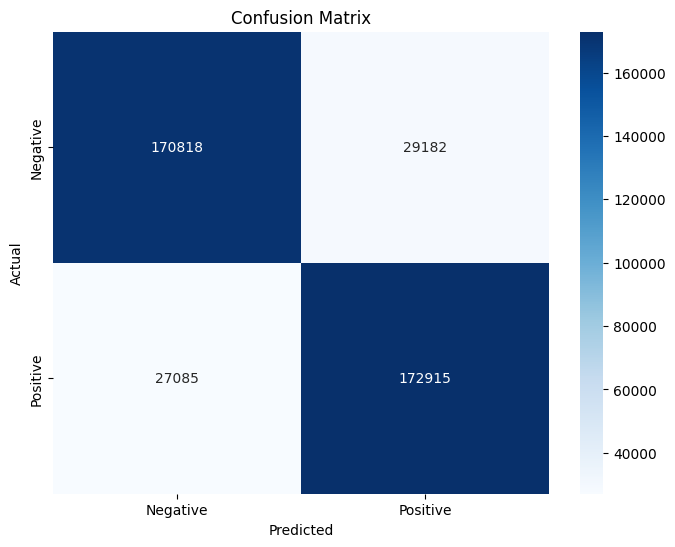


Detailed Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.86    200000
    Positive       0.86      0.86      0.86    200000

    accuracy                           0.86    400000
   macro avg       0.86      0.86      0.86    400000
weighted avg       0.86      0.86      0.86    400000



In [15]:
# Import necessary metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

# Print metrics
print("Model Performance Metrics:")
print("-" * 50)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Create confusion matrix visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print detailed classification report
print("\nDetailed Classification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np

# Set style for better visualizations
plt.style.use('default')
fig = plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

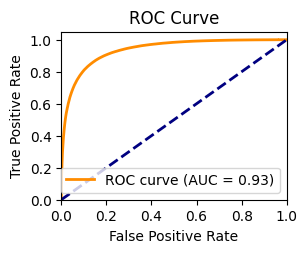

In [20]:
# 1. ROC Curve
plt.subplot(2, 2, 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba, pos_label=2)  # Specify pos_label=2 for positive class
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")


Text(0.5, 0, 'Absolute Coefficient Value')

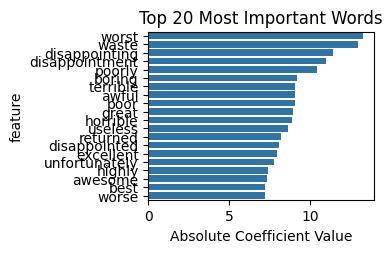

In [21]:
# 2. Feature Importance (Top 20 words)
plt.subplot(2, 2, 2)
feature_importance = pd.DataFrame({
    'feature': vectorizer.get_feature_names_out(),
    'importance': abs(model.coef_[0])
})
feature_importance = feature_importance.sort_values('importance', ascending=False).head(20)
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Top 20 Most Important Words')
plt.xlabel('Absolute Coefficient Value')

Text(0, 0.5, 'Count')

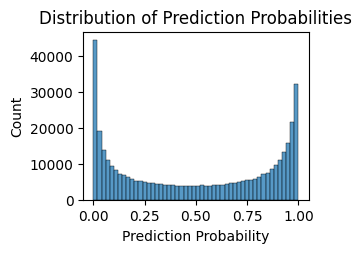

In [22]:
# 3. Prediction Distribution
plt.subplot(2, 2, 3)
sns.histplot(y_pred_proba, bins=50)
plt.title('Distribution of Prediction Probabilities')
plt.xlabel('Prediction Probability')
plt.ylabel('Count')


Text(321.26767676767673, 0.5, 'Actual')

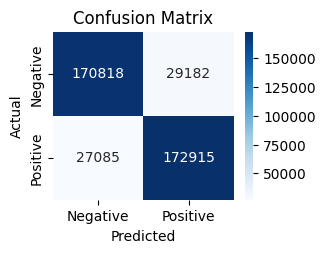

In [23]:
# 4. Confusion Matrix Heatmap
plt.subplot(2, 2, 4)
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


In [24]:
# Adjust layout and display
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [25]:
# Print additional insights
print("\nModel Insights:")
print("-" * 50)
print(f"1. Model Confidence:")
print(f"   - Average prediction probability: {np.mean(y_pred_proba):.3f}")
print(f"   - Standard deviation: {np.std(y_pred_proba):.3f}")
print(f"   - Most confident predictions: {np.percentile(y_pred_proba, 95):.3f}")

print("\n2. Feature Analysis:")
print(f"   - Most positive word: {feature_importance.iloc[0]['feature']}")
print(f"   - Most negative word: {feature_importance.iloc[-1]['feature']}")

print("\n3. Model Performance Summary:")
print(f"   - ROC AUC Score: {roc_auc:.3f}")
print(f"   - Balanced Accuracy: {accuracy_score(y_test, y_pred):.3f}")


Model Insights:
--------------------------------------------------
1. Model Confidence:
   - Average prediction probability: 0.500
   - Standard deviation: 0.372
   - Most confident predictions: 0.989

2. Feature Analysis:
   - Most positive word: worst
   - Most negative word: worse

3. Model Performance Summary:
   - ROC AUC Score: 0.935
   - Balanced Accuracy: 0.859
